# Batch 1 배터리 수명 모델링

전처리한 `Data/batch1_features.csv`를 사용합니다. 로컬 Jupyter에서 위에서 아래로 실행합니다.

1. 충전 프로토콜 단위로 약 20%를 Hold-out으로 남깁니다.
2. 나머지 학습 데이터에서 5-fold 그룹 교차검증으로 모델과 설정을 비교합니다.
3. 교차검증 평균 MAPE가 가장 낮은 모델만 Hold-out에서 평가합니다.

입력은 `delta_q_min`, `QD_change_10_100`, `mean_Tavg`이고 정답은 `cycle_life`입니다. 모델 선택에는 Batch 2·3을 사용하지 않습니다. Batch 2는 마지막 셀에서 최종 평가합니다. 결측값 대체와 셀 제외를 하지 않습니다.

필요 패키지: numpy, pandas, matplotlib, scikit-learn, optuna. 프로젝트 의존성은 `%pip install -r requirment.txt`로 설치한 뒤 커널을 재시작해 주십시오.


In [74]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import optuna
from sklearn.base import clone
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error

ROOT = Path.cwd().resolve()

DATA_PATH = ROOT / "Data" / "batch1_features.csv"
FEATURE_COLUMNS = ["delta_q_min", "QD_change_10_100", "mean_Tavg"]
TARGET_COLUMN = "cycle_life"
GROUP_COLUMN = "charging_policy"
HOLDOUT_RATIO = 0.20
RANDOM_STATE = 42
CV_FOLDS = 5
N_TRIALS = 500  # Ridge, Huber, SVR 각각의 탐색 횟수

print(f"scikit-learn: {sklearn.__version__}")
print(f"입력 CSV: {DATA_PATH}")


scikit-learn: 1.9.1
입력 CSV: /Users/uk/Desktop/archive/Data/batch1_features.csv


## 1. 전처리 데이터 로딩

식별자, 배치, 충전 프로토콜은 모델 입력에서 제외합니다. 데이터를 정렬해 같은 CSV에서 동일한 분할을 재현할 수 있게 합니다. 원본 CSV는 수정하지 않습니다.


In [75]:
features_df = pd.read_csv(DATA_PATH).sort_values("source_cell_index").reset_index(drop=True)

X = features_df[FEATURE_COLUMNS]
y = features_df[TARGET_COLUMN]
groups = features_df[GROUP_COLUMN]

print(f"셀 수: {len(features_df)}")
print(f"충전 프로토콜 수: {groups.nunique()}")
display(features_df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())


셀 수: 46
충전 프로토콜 수: 23


,delta_q_min,QD_change_10_100,mean_Tavg,cycle_life
0,-0.008460,0.001375,31.603747,1190.0
1,-0.011004,0.000853,31.330314,1179.0
2,-0.017216,0.001159,31.479584,1177.0
3,-0.018961,0.000442,29.942199,1226.0
4,-0.013958,0.000692,31.448884,1227.0


## 2. 약 20% Hold-out 분리

`GroupShuffleSplit(test_size=0.2)`의 20%는 **셀 수가 아니라 프로토콜 그룹 수**를 기준으로 합니다. 그룹 크기가 다르므로 실제 검증 셀 비율은 달라질 수 있습니다. 난수 시드는 42로 고정하며, 성능을 보고 분할을 다시 고르지 않습니다.

GroupShuffleSplit이 같은 프로토콜의 셀을 한쪽에 묶어 분리합니다. 모델 선택에는 Hold-out의 정답과 성능을 사용하지 않습니다.

참고: [scikit-learn GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html)


In [76]:
splitter = GroupShuffleSplit(
    n_splits=1, test_size=HOLDOUT_RATIO, random_state=RANDOM_STATE
)
train_index, valid_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
y_train = y.iloc[train_index]
groups_train = groups.iloc[train_index]
X_valid = X.iloc[valid_index]
y_valid = y.iloc[valid_index]
groups_valid = groups.iloc[valid_index]

split_summary = pd.DataFrame([
    {"split": "Train", "cells": len(train_index), "policy_groups": groups_train.nunique()},
    {"split": "Hold-out", "cells": len(valid_index), "policy_groups": groups_valid.nunique()},
])
display(split_summary)
print(f"실제 Hold-out 셀 비율: {len(valid_index) / len(features_df):.1%}")
print("Hold-out 셀:", features_df.iloc[valid_index]["cell_id"].tolist())


,split,cells,policy_groups
0,Train,35,18
1,Hold-out,11,5


실제 Hold-out 셀 비율: 23.9%
Hold-out 셀: ['b1c0', 'b1c1', 'b1c2', 'b1c14', 'b1c15', 'b1c18', 'b1c19', 'b1c28', 'b1c29', 'b1c34', 'b1c35']


## 3. 학습 데이터 내 교차검증과 모델 비교

5-fold GroupKFold로 프로토콜이 교차검증의 학습·검증에 겹치지 않도록 합니다. 표준화는 Pipeline 안에 넣어 각 fold의 학습 데이터에서만 계산합니다.

- Median baseline: 학습 수명 중앙값만 예측하는 기준선
- LinearRegression: 선형회귀
- Ridge: 규제를 적용한 선형회귀
- Huber: 큰 잔차에 덜 민감한 회귀
- RBF-SVR: 비선형 회귀

Optuna의 TPE 탐색으로 연속 범위 안에서 값을 제안합니다. 처음 10회는 무작위로 탐색하고, 이후에는 이전 교차검증 결과를 바탕으로 다음 값을 제안합니다. Ridge·Huber·SVR 각각 `N_TRIALS = 60`회 탐색하며, 학습 데이터의 교차검증 점수만으로 비교합니다.

탐색 범위는 `SEARCH_RANGES`에 `(최솟값, 최댓값, 로그 척도 여부)`로 지정합니다. 로그 척도는 작은 값부터 큰 값까지 여러 자릿수에 걸친 범위를 탐색할 때 사용합니다. 유한 횟수의 탐색이므로 범위 전체의 최적값을 보장하지는 않습니다. MAPE는 백분율로 표시합니다. CV 평균은 fold별 MAPE의 단순 평균이고 CV 표준편차는 신뢰구간이 아닙니다. 최적 설정을 고르는 데 사용한 CV 값은 독립적인 최종 성능 추정치가 아닙니다.

참고: [scikit-learn 교차검증](https://scikit-learn.org/stable/modules/cross_validation.html), [Optuna TPE 탐색](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html)

저장된 출력은 마지막 실행 당시의 결과입니다. 탐색 방식을 바꾼 뒤에는 설정 셀부터 모델 선택 셀까지 다시 실행하여 갱신합니다.


In [77]:
cv = GroupKFold(n_splits=CV_FOLDS)
cv_splits = list(cv.split(X_train, y_train, groups=groups_train))

candidates = {
    "Median baseline": DummyRegressor(strategy="median"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Huber": HuberRegressor(max_iter=2000),
    "RBF-SVR": SVR(kernel="rbf"),
}

# (최솟값, 최댓값, 로그 척도 여부): 고정 후보 목록 없이 범위에서 탐색합니다.
SEARCH_RANGES = {
    "Ridge": {
        "alpha": (0.0001, 1000.0, True),
    },
    "Huber": {
        "alpha": (0.00001, 10.0, True),
        "epsilon": (1.0, 3.0, False),
    },
    "RBF-SVR": {
        "C": (1.0, 200000.0, True),
        "gamma": (0.0001, 1.0, True),
        "epsilon": (1.0, 10.0, False),
    },
}


def build_pipeline(model, params):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", clone(model).set_params(**params)),
    ])


def evaluate_cv(model, params):
    scores = cross_val_score(
        build_pipeline(model, params),
        X_train,
        y_train,
        scoring="neg_mean_absolute_percentage_error",
        cv=cv_splits,
        n_jobs=1,
        error_score="raise",
    )
    return -100 * scores


optuna.logging.set_verbosity(optuna.logging.WARNING)
studies = {}
best_params_by_model = {}
cv_records = []

for name, model in candidates.items():
    if name in SEARCH_RANGES:
        def objective(trial):
            params = {
                parameter: trial.suggest_float(parameter, low, high, log=use_log)
                for parameter, (low, high, use_log) in SEARCH_RANGES[name].items()
            }
            fold_mape = evaluate_cv(model, params)
            trial.set_user_attr("cv_std_mape_pct", float(fold_mape.std()))
            return float(fold_mape.mean())

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(
                seed=RANDOM_STATE, n_startup_trials=10
            ),
        )
        study.optimize(objective, n_trials=N_TRIALS, n_jobs=1)
        studies[name] = study
        best_params = study.best_params
        mean_mape = study.best_value
        std_mape = study.best_trial.user_attrs["cv_std_mape_pct"]
    else:
        # 중앙값 기준선과 선형회귀는 조정할 파라미터 없이 평가합니다.
        best_params = {}
        fold_mape = evaluate_cv(model, best_params)
        mean_mape = float(fold_mape.mean())
        std_mape = float(fold_mape.std())

    best_params_by_model[name] = best_params
    cv_records.append({
        "model": name,
        "cv_mean_mape_pct": mean_mape,
        "cv_std_mape_pct": std_mape,
        "best_params": best_params,
    })

cv_results_df = (
    pd.DataFrame(cv_records)
    .sort_values("cv_mean_mape_pct", kind="stable")
    .reset_index(drop=True)
)
display(cv_results_df)

best_name = cv_results_df.iloc[0]["model"]
best_cv_mape = float(cv_results_df.iloc[0]["cv_mean_mape_pct"])
best_params = best_params_by_model[best_name]
best_model = build_pipeline(candidates[best_name], best_params)
best_model.fit(X_train, y_train)

print(f"교차검증으로 선택한 모델: {best_name}")
print("선택한 설정:", best_params)


,model,cv_mean_mape_pct,cv_std_mape_pct,best_params
0,RBF-SVR,7.650578,2.391587,"{'C': 61901.9925067011, 'gamma': 0.00335841407..."
1,Huber,8.283887,2.530000,"{'alpha': 0.06317788821178884, 'epsilon': 2.54..."
2,Ridge,8.315266,2.584440,{'alpha': 5.512126422325104}
3,LinearRegression,8.948765,1.547984,{}
4,Median baseline,19.627185,9.145810,{}


교차검증으로 선택한 모델: RBF-SVR
선택한 설정: {'C': 61901.9925067011, 'gamma': 0.003358414074222409, 'epsilon': 3.074011265778389}


## 4. 선택한 모델의 Hold-out 평가

선택된 Pipeline은 학습 데이터 전체에 이미 재학습되어 있습니다. 이 모델로 Hold-out을 평가합니다. Hold-out 결과를 보고 모델, 설정, 난수 시드를 다시 선택하지 않습니다.

`Gap = Hold-out MAPE − 학습 데이터 CV 평균 MAPE`이며 단위는 퍼센트포인트입니다. 양의 차이는 일반화 성능 저하를 점검할 신호이지만, 표본이 작고 학습 크기가 달라 과적합의 확정적 증거로 해석하지 않습니다.


In [78]:
valid_prediction = best_model.predict(X_valid)
valid_mape = 100 * mean_absolute_percentage_error(y_valid, valid_prediction)

performance_df = pd.DataFrame([{
    "model": best_name,
    "train_cv_mape_pct": best_cv_mape,
    "valid_holdout_mape_pct": valid_mape,
    "gap_valid_minus_cv_pp": valid_mape - best_cv_mape,
}])
display(performance_df)

valid_predictions_df = features_df.iloc[valid_index][
    ["cell_id", GROUP_COLUMN, TARGET_COLUMN]
].copy()
valid_predictions_df["predicted_cycle_life"] = valid_prediction
valid_predictions_df["residual_actual_minus_predicted"] = y_valid.to_numpy() - valid_prediction
valid_predictions_df["absolute_percentage_error_pct"] = (
    100 * np.abs(y_valid.to_numpy() - valid_prediction) / y_valid.to_numpy()
)
display(valid_predictions_df.sort_values("absolute_percentage_error_pct", ascending=False))
print(f"0 이하 예측 수: {np.count_nonzero(valid_prediction <= 0)}")


,model,train_cv_mape_pct,valid_holdout_mape_pct,gap_valid_minus_cv_pp
0,RBF-SVR,7.650578,9.741548,2.09097


,cell_id,charging_policy,cycle_life,predicted_cycle_life,residual_actual_minus_predicted,absolute_percentage_error_pct
15,b1c15,5.4C(60%)-3C,719.0,896.011791,-177.011791,24.619164
18,b1c18,5.4C(70%)-3C,691.0,784.791760,-93.791760,13.573337
35,b1c35,7C(30%)-3.6C,703.0,795.414146,-92.414146,13.145682
34,b1c34,7C(30%)-3.6C,742.0,815.878450,-73.878450,9.956664
29,b1c29,6C(50%)-3C,917.0,829.088866,87.911134,9.586819
19,b1c19,5.4C(70%)-3C,788.0,716.073381,71.926619,9.127744
0,b1c0,3.6C(80%)-3.6C,1190.0,1293.206578,-103.206578,8.672822
1,b1c1,3.6C(80%)-3.6C,1179.0,1274.231338,-95.231338,8.077298
28,b1c28,6C(50%)-3C,860.0,821.320781,38.679219,4.497584
14,b1c14,5.4C(60%)-3C,880.0,909.845391,-29.845391,3.391522


0 이하 예측 수: 0


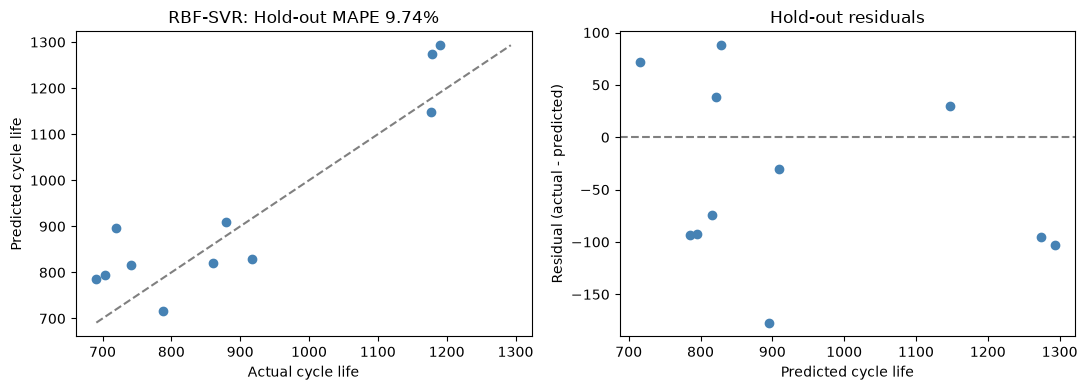

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lower = min(y_valid.min(), valid_prediction.min())
upper = max(y_valid.max(), valid_prediction.max())

axes[0].scatter(y_valid, valid_prediction, color="steelblue")
axes[0].plot([lower, upper], [lower, upper], "--", color="gray")
axes[0].set_xlabel("Actual cycle life")
axes[0].set_ylabel("Predicted cycle life")
axes[0].set_title(f"{best_name}: Hold-out MAPE {valid_mape:.2f}%")

axes[1].scatter(
    valid_prediction,
    y_valid.to_numpy() - valid_prediction,
    color="steelblue",
)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_xlabel("Predicted cycle life")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Hold-out residuals")
plt.tight_layout()
plt.show()


## 5. TEST 데이터를 통한 테스트 수행

모델과 설정을 확정한 뒤 Batch 2를 전처리하여 최종 테스트합니다. 이 노트북은 데이터, 모델 파일, 결과 CSV를 자동 저장하지 않습니다. 모델 객체는 `best_model`, 교차검증 결과는 `cv_results_df`, Hold-out 결과는 `performance_df`와 `valid_predictions_df`에 남습니다.


In [80]:
# Batch 2는 이미 학습한 모델의 최종 테스트에만 사용합니다.
test_df = pd.read_csv(ROOT / "Data" / "batch2_features.csv")
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

# best_model에 포함된 Batch 1 기준 표준화도 자동으로 적용됩니다.
test_prediction = best_model.predict(X_test)
test_mape = 100 * mean_absolute_percentage_error(y_test, test_prediction)

test_performance_df = performance_df.copy()
test_performance_df["test_batch2_mape_pct"] = test_mape
test_performance_df["gap_test_minus_valid_pp"] = test_mape - valid_mape
display(test_performance_df)

test_predictions_df = test_df[["cell_id", TARGET_COLUMN]].copy()
test_predictions_df["predicted_cycle_life"] = test_prediction
test_predictions_df["absolute_percentage_error_pct"] = (
    100 * np.abs(y_test.to_numpy() - test_prediction) / y_test.to_numpy()
)
display(test_predictions_df.head())
print(f"Batch 2 테스트 셀 수: {len(test_df)}")
print(f"Batch 2 테스트 MAPE: {test_mape:.2f}%")


,model,train_cv_mape_pct,valid_holdout_mape_pct,gap_valid_minus_cv_pp,test_batch2_mape_pct,gap_test_minus_valid_pp
0,RBF-SVR,7.650578,9.741548,2.09097,18.630725,8.889176


,cell_id,cycle_life,predicted_cycle_life,absolute_percentage_error_pct
0,b2c0,477.0,571.357080,19.781358
1,b2c1,491.0,558.574876,13.762704
2,b2c2,424.0,678.604136,60.048145
3,b2c3,499.0,568.539159,13.935703
4,b2c4,444.0,506.720072,14.126142


Batch 2 테스트 셀 수: 39
Batch 2 테스트 MAPE: 18.63%
